This notebook conducts enrichment analysis and creates plots of the relative risk of each variant type for expression outliers.

This notebook should take about a minute to run.

## Setup

In [1]:
!pip install polars==0.18.6
!pip install pyranges
!pip install pysam


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  Using cached pyranges-0.1.4-py3-none-any.whl.metadata (3.7 kB)
  Using cached ncls-0.0.70-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.9 kB)
  Using cached sorted_nearest-0.0.41.tar.gz (1.6 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 82.1 MB/s eta 0:00:00
  Created wheel for sorted_nearest: filename=sorted_nearest-0.0.41-cp310-cp310-linux_x86_64.whl size=2657350 sha256=b0bebd5c76bc01931842e12947d479fa8209a84f86142eacf24645476a8c8214
  Stored in directory: /home/jupyter/.cache/pip/wheels/ed/31/af/4e5ee693ca5804e4696d888e42c8c2833b5e56819a43f900a9
Successfully built sorted_nearest

[notice] A new release of pip is available: 2

In [2]:
import polars as pl
import pandas as pd
import numpy as np
import re
from scipy import stats
from pysam import VariantFile
from firecloud import fiss

from matplotlib import pyplot as plt
import statsmodels.formula.api as smf
from itertools import product
import os
import io

In [3]:
def extract_vcf_field(vcf_path,fields=['MAF']):
    additional_SV_info = []
    vcf_read = VariantFile(vcf_path,'r')
    for rec in vcf_read.fetch():
        additional_SV_info.append([rec.id]+[rec.info[i] if i in rec.info else None for i in fields])
    return pd.DataFrame(additional_SV_info,columns=['SV']+fields)

def relative_risk_confidence_interval(table_in):
    table = table_in.copy()
    table['log_RR'] = np.log(table['enrichment'])
    table['log_lowB']  = table['log_RR'] - 1.96*(np.sqrt(1/table['1,1']+1/table['1,0']+1/table['0,1']+1/table['0,0']))
    table['log_highB'] = table['log_RR'] + 1.96*(np.sqrt(1/table['1,1']+1/table['1,0']+1/table['0,1']+1/table['0,0']))
    table['dlowB']  = table['enrichment']-np.exp(table['log_lowB'])
    table['dhighB'] = np.exp(table['log_highB'])-table['enrichment']
    table['dlog_lowB']  = table['log_RR']-table['log_lowB']
    table['dlog_highB'] = table['log_highB']-table['log_RR']
    return table

def fill_contingency_count(df,prefix1:str,prefix2:str,y:int,svtype:str):
    exist=[j[0] for j in df.select(pl.col(f'{prefix1}_{y}_{svtype}').struct.field(f"{prefix2}_{svtype}")).rows()]
    for i in [[0,0],[0,1],[1,0],[1,1]]:
        if i not in exist:
            new_row_dict = {f'{prefix1}_{y}_{svtype}':{f'{prefix2}_{svtype}': i, 'count': 0}}
            new_row_df = pl.DataFrame([new_row_dict]).select(pl.struct([
                pl.col(f'{prefix1}_{y}_{svtype}').struct.field(f'{prefix2}_{svtype}').cast(pl.List(pl.Int32)),
                pl.col(f'{prefix1}_{y}_{svtype}').struct.field('count').cast(pl.UInt32)
            ]).alias(f'{prefix1}_{y}_{svtype}'))
            df = pl.concat([df, new_row_df])
    return df

Here we read references to the files that were output by our workflow from the Terra data table.

In [4]:
tbl = pd.read_csv(io.StringIO(fiss.fapi.get_entities_tsv(
  namespace = os.environ['WORKSPACE_NAMESPACE'],
  workspace = os.environ['WORKSPACE_NAME'],
  etype = 'watershed_sv_run',
  model='flexible').text), sep='\t')

Extract some extra intermediate outputs from the Watershed-SV workflow run submission directory

In [5]:
pipeline_input_genotypes = re.sub(
    r"call-.*$",
    "call-extract_rare_variants/pipeline_input_genotypes.tsv",
    tbl.at[0,'combined_annotations']
)

gene_sv_bed = re.sub(
    r"call-.*$",
    "call-sv_to_gene_processing/gene_sv.10000.bed",
    tbl.at[0,'combined_annotations']
)

vep = re.sub(
    r"call-.*$",
    "call-vep_post_processing/sv_to_gene_vep.10000.tsv",
    tbl.at[0,'combined_annotations']
)

In [6]:
!gcloud storage cp "$WORKSPACE_BUCKET/data/derived/ALL.wgs.mergedSV.v8.20130502.svs.genotypes-edited.vcf.gz" .
!gcloud storage cp "$WORKSPACE_BUCKET/data/derived/mage_expression-watershed_sv_input.tsv" .
!gcloud storage cp "$WORKSPACE_BUCKET/data/derived/mage_expression-watershed_sv_input-400_random_pairs.tsv" .
!gcloud storage cp "$WORKSPACE_BUCKET/data/derived/1kGp3_sv_maf_file.tsv" .
!gcloud storage cp "{pipeline_input_genotypes}" .
!gcloud storage cp "{gene_sv_bed}" .
!gcloud storage cp "{vep}" .

Copying gs://fc-secure-ca459dc2-db2a-4dbb-8747-baea7e6c6669/data/derived/ALL.wgs.mergedSV.v8.20130502.svs.genotypes-edited.vcf.gz to file://./ALL.wgs.mergedSV.v8.20130502.svs.genotypes-edited.vcf.gz
  Completed files 1/1 | 10.0MiB/10.0MiB                                        

Average throughput: 63.1MiB/s
Copying gs://fc-secure-ca459dc2-db2a-4dbb-8747-baea7e6c6669/data/derived/mage_expression-watershed_sv_input.tsv to file://./mage_expression-watershed_sv_input.tsv
  Completed files 1/1 | 98.9MiB/98.9MiB                                        

Average throughput: 195.0MiB/s
Copying gs://fc-secure-ca459dc2-db2a-4dbb-8747-baea7e6c6669/data/derived/mage_expression-watershed_sv_input-400_random_pairs.tsv to file://./mage_expression-watershed_sv_input-400_random_pairs.tsv
  Completed files 1/1 | 1.2MiB/1.2MiB                                          

Average throughput: 141.7MiB/s
Copying gs://fc-secure-ca459dc2-db2a-4dbb-8747-baea7e6c6669/data/derived/1kGp3_sv_maf_file.tsv to file://.

# Preprocessing
Reading in and formatting various auxilliary information.

In [7]:
vcf = 'ALL.wgs.mergedSV.v8.20130502.svs.genotypes-edited.vcf.gz'
sv_genotypes = pl.scan_csv('pipeline_input_genotypes.tsv',separator='\t',dtypes={'SV':str})

gene_sv_overlap = pl.scan_csv('gene_sv.10000.bed', separator='\t', dtypes={'SV':str},
    new_columns=['chrom','start','end','SV','SVTYPE','gene']
).with_columns(pl.col('gene').str.split('.').list.first())

svlens = extract_vcf_field(vcf,fields=['SVLEN'])
svlens['SVLEN'] = [int(i[1][0]) for i in svlens['SVLEN'].items()]
svlen_gt_30 = set(svlens[svlens.SVLEN.abs()>30].SV)

vep  = pl.read_csv('sv_to_gene_vep.10000.tsv', separator='\t').rename({'Gene':'gene'})
MAFs = pl.read_csv('1kGp3_sv_maf_file.tsv', separator='\t').lazy()

[E::idx_find_and_load] Could not retrieve index file for 'ALL.wgs.mergedSV.v8.20130502.svs.genotypes-edited.vcf.gz'


Expression data.

In [8]:
expression_file = 'mage_expression-watershed_sv_input-400_random_pairs.tsv'
#expression_file = 'mage_expression-watershed_sv_input.tsv' # You can uncomment this line to run with all samples.

lymphoblast = pl.scan_csv(expression_file,separator='\t').with_columns([
    pl.when(pl.col('MedZ').abs() > 3).then(1).otherwise(0).alias('Y'),
    pl.col('gene').str.split('.').list[0].alias('gene')
])

# Global outlier filter
num_outliers = lymphoblast.collect()
IQR = stats.iqr(num_outliers['Y'])
Q3 = np.percentile(num_outliers['Y'],75)
Q1 = np.percentile(num_outliers['Y'],25)
samples_to_keep = num_outliers.filter(pl.col('Y') <= 1.5*IQR+Q3)['Ind']
lymphoblast = lymphoblast.filter(pl.col('Ind').is_in(samples_to_keep))

# Enrichment analysis using 10 kb flanks

In [9]:
enrichment_grid = list(product(list(range(1,6)),['DEL','INS','DUP','INV']))

rare_svs=MAFs.with_columns(pl.when(pl.col('af')<0.01).then('rare').otherwise('common').alias('rareness')).select(['SV','af','rareness']).collect()

rare_genotypes = sv_genotypes.filter((pl.col('Allele')>0)).join(rare_svs.lazy(),on='SV').\
collect().rename({'SUBJID':'Ind'}).lazy()

genotype_ind = set(rare_genotypes.select('Ind').collect()['Ind'])
expression_ind = set(lymphoblast.select('Ind').collect()['Ind'])
subset_to_use = list(genotype_ind.intersection(expression_ind))

relevant_outliers=lymphoblast.filter(pl.col('Ind').is_in(subset_to_use)).with_columns([pl.when(pl.col('MedZ').abs() > i).then(1).otherwise(0).alias(f"Y{i}") for i in range(1,6)])
relevant_outliers=relevant_outliers.with_columns([pl.when(pl.col(f'Y{i}').sum().over('gene')>0).then(1).otherwise(0).alias(f"Y{i}_background") for i in range(1,6)])

rare_genotypes = rare_genotypes.filter(pl.col('Ind').is_in(subset_to_use))
rare_sv_enrichment = relevant_outliers.join(gene_sv_overlap.select(['gene','SV']),on='gene',how='left').\
join(rare_genotypes,on=['Ind','SV'],how='left').\
with_columns([
    pl.when(pl.col('rareness')=='rare').then(1).otherwise(0).alias('has_rare_SV'),
    pl.when(pl.col('rareness')=='common').then(1).otherwise(0).alias('has_common_SV'),
    pl.when((pl.col('rareness')=='rare')&(pl.col('SVTYPE')=='DUP')).then(1).otherwise(0).alias('has_rare_DUP'),
    pl.when((pl.col('rareness')=='rare')&(pl.col('SVTYPE')=='DEL')).then(1).otherwise(0).alias('has_rare_DEL'),
    pl.when((pl.col('rareness')=='rare')&(pl.col('SVTYPE')=='INS')).then(1).otherwise(0).alias('has_rare_INS'),
    pl.when((pl.col('rareness')=='rare')&(pl.col('SVTYPE')=='INV')).then(1).otherwise(0).alias('has_rare_INV'),
]).collect()

rare_sv_enrichment_gene = rare_sv_enrichment.groupby(['gene','Ind']).agg(pl.col("MedZ").first(),
                                                   pl.col("Y").first(),
                                                   pl.col("Y1").first(),
                                                   pl.col("Y2").first(),
                                                   pl.col("Y3").first(),
                                                   pl.col("Y4").first(),
                                                   pl.col("Y5").first(),
                                                   pl.col("Y1_background").first(),
                                                   pl.col("Y2_background").first(),
                                                   pl.col("Y3_background").first(),
                                                   pl.col("Y4_background").first(),
                                                   pl.col("Y5_background").first(),
                                                   pl.col("Allele").max(),
                                                   pl.col("has_rare_SV").max(),
                                                   pl.col("has_common_SV").max(),
                                                   pl.col("has_rare_DUP").max(),
                                                   pl.col("has_rare_DEL").max(),
                                                   pl.col("has_rare_INS").max(),
                                                   pl.col("has_rare_INV").max())
enrichment_using_statsmodels = rare_sv_enrichment_gene.fill_null(0).select(['gene','MedZ','Y','Ind',
                                                                                   'Y1','Y2','Y3','Y4','Y5',
                                                                                   'Y1_background','Y2_background',
                                                                                   'Y3_background','Y4_background',
                                                                                   'Y5_background','has_rare_SV','has_common_SV',
                                                                                   'has_rare_DUP','has_rare_DEL','has_rare_INS',
                                                                                   'has_rare_INV']).to_pandas()
enrichment_results = []
for i in range(1,6):
    model = smf.logit(f'Y{i} ~ has_rare_DUP + has_rare_DEL',
              data = enrichment_using_statsmodels[enrichment_using_statsmodels[f'Y{i}_background']==1]).fit()
    enrichment_results.append(
        pd.DataFrame({'SVTYPE':['DUP','DEL'],
                      'log_OR':[model.params['has_rare_DUP'],model.params['has_rare_DEL']],
                      'SE':[model.bse['has_rare_DUP'],model.bse['has_rare_DEL']],
                      'P-value': [model.pvalues['has_rare_DUP'],model.pvalues['has_rare_DEL']],
                      'Z-threshold':i}))
enrichment_df = pd.concat(enrichment_results) 

Optimization terminated successfully.
         Current function value: 0.570190
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.168998
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.052233
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.030447
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.020780
         Iterations 10


There are not enough INVs nor INSs for the model to converge, so we must exclude them.

In [10]:
print(enrichment_using_statsmodels['has_rare_DUP'].sum(),
      enrichment_using_statsmodels['has_rare_DEL'].sum(),
      enrichment_using_statsmodels['has_rare_INS'].sum(),
      enrichment_using_statsmodels['has_rare_INV'].sum())

31 218 0 2


Text(0, 0.5, 'log(OR)')

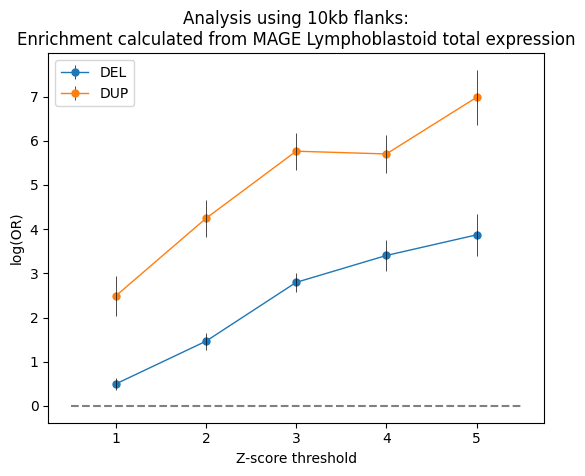

In [11]:
for svtype in ['DEL','DUP']:
    plt.errorbar(enrichment_df.loc[enrichment_df['SVTYPE']==svtype,'Z-threshold'],
                 enrichment_df.loc[enrichment_df['SVTYPE']==svtype,'log_OR'],
                 enrichment_df.loc[enrichment_df['SVTYPE']==svtype,['SE','SE']].to_numpy().T,
                 label=svtype,
                 ecolor='black',
                 elinewidth=0.5,barsabove=True,
                 linewidth=1,marker='.',markersize=10)
plt.hlines(y=0,xmax=5.5,xmin=0.5,linestyles='dashed',colors='gray')
plt.legend(loc='upper left')
plt.title('Analysis using 10kb flanks:\nEnrichment calculated from MAGE Lymphoblastoid total expression')
plt.xlabel('Z-score threshold')
plt.ylabel('log(OR)')

The above plot shows the enrichment for different SV types for different severities of outliers. SVs overlapping or within 10kb of the genes are considered.

# Gene-centric analysis

In [12]:
enrichment_grid = list(product(list(range(1,6)),['DEL','DUP']))
enrichment_grid_2 = list(product(list(range(1,6)),['coding_variant','noncoding_variant','NO_rareSV']))

In [13]:
rare_svs=set(MAFs.filter((pl.col('af')<0.01)).select('SV').collect().to_series())
rare_svs_30=pl.DataFrame(pl.Series('SV',list(rare_svs.intersection(svlen_gt_30))))

rare_genotypes = sv_genotypes.filter((pl.col('Allele')>0)).join(rare_svs_30.lazy(),on='SV').\
collect().rename({'SUBJID':'Ind'}).lazy()

relevant_outliers=lymphoblast.with_columns([pl.when(pl.col('MedZ').abs() > i).then(1).otherwise(0).alias(f"Y{i}") for i in range(1,6)])
rare_sv_enrichment = relevant_outliers.join(gene_sv_overlap.select(['gene','SV']),on='gene',how='left').\
join(rare_genotypes,on=['Ind','SV'],how='left').\
with_columns([
    pl.when(pl.col('Allele').is_null()).then(0).otherwise(1).alias('has_rare_SV'),
    pl.when(~(pl.col('Allele').is_null())&(pl.col('SVTYPE')=='DUP')).then(1).otherwise(0).alias('has_rare_DUP'),
    pl.when(~(pl.col('Allele').is_null())&(pl.col('SVTYPE')=='DEL')).then(1).otherwise(0).alias('has_rare_DEL'),
    pl.when(~(pl.col('Allele').is_null())&(pl.col('SVTYPE')=='INS')).then(1).otherwise(0).alias('has_rare_INS'),
    pl.when(~(pl.col('Allele').is_null())&(pl.col('SVTYPE')=='INV')).then(1).otherwise(0).alias('has_rare_INV')
]).collect()

# Appending coding sequence annotation
rare_sv_enrichment = rare_sv_enrichment.join(vep.select(['gene','SV','coding_sequence_variant']),on=['gene','SV'],how='left')
    
rare_sv_enrichment_gene = rare_sv_enrichment.groupby(['gene','Ind']).agg(pl.col("MedZ").first(),
                                                   pl.col("Y").first(),
                                                   pl.col("Y1").first(),
                                                   pl.col("Y2").first(),
                                                   pl.col("Y3").first(),
                                                   pl.col("Y4").first(),
                                                   pl.col("Y5").first(),
                                                   pl.col("Allele").max(),
                                                   pl.col("has_rare_SV").max(),
                                                   pl.col("has_rare_DUP").max(),
                                                   pl.col("has_rare_DEL").max(),
                                                   pl.col("has_rare_INS").max(),
                                                   pl.col("has_rare_INV").max(),
                                                   pl.col('coding_sequence_variant').max())

rare_sv_enrichment_gene_with_collapse_types = rare_sv_enrichment_gene.\
with_columns([
    pl.when((pl.col('has_rare_DUP')==1)).then('DUP').
    when((pl.col('has_rare_DEL')==1)).then('DEL').
    when((pl.col('has_rare_INS')==1)).then('INS').
    when((pl.col('has_rare_INV')==1)).then('INV').
    otherwise('NO_rareSV').
    alias('has_rare_SVTYPE_collapsed'),
    pl.when(pl.col('coding_sequence_variant')==1).then('coding_variant').
    when((pl.col('coding_sequence_variant')==0)&(pl.col('Allele').is_not_null())).then('noncoding_variant').
    otherwise('NO_rareSV').
    alias('has_rare_category')
])
rare_sv_enrichment_gene_with_collapse_types = pl.concat([rare_sv_enrichment_gene_with_collapse_types,rare_sv_enrichment_gene_with_collapse_types.
                                                                select(['has_rare_SVTYPE_collapsed','has_rare_category']).to_dummies()],how='horizontal')
enriched_sv_genes_collapsed_noConflict_list = []

for i,j in enrichment_grid:
    enriched_sv_genes_collapsed_noConflict_list.append(fill_contingency_count(rare_sv_enrichment_gene_with_collapse_types.\
select(pl.concat_list(pl.col([f'Y{i}',f'has_rare_SVTYPE_collapsed_{j}'])).alias(f'Y_has_rare_SVTYPE_collapsed_{j}').
        value_counts(sort=False).struct.rename_fields([f'Y_has_rare_SVTYPE_collapsed_{j}','count']).
        alias(f'Gene_cat_count_{i}_{j}')),'Gene_cat_count','Y_has_rare_SVTYPE_collapsed',i,j))

enriched_sv_genes_collapsed_noConflict = pl.concat(enriched_sv_genes_collapsed_noConflict_list, how="horizontal")


contingency_tables_gene_noConflict=[enriched_sv_genes_collapsed_noConflict.select(pl.col(f'Gene_cat_count_{i}_{j}').struct.field(f'Y_has_rare_SVTYPE_collapsed_{j}').cast(pl.List(str)).list.join(","),
                             pl.col(f'Gene_cat_count_{i}_{j}').struct.field('count').alias(f'count_Y{i}_{j}'),
                            ) for i,j in enrichment_grid]

contingency_table_gene_noConflict = contingency_tables_gene_noConflict[0]
for i in range(1,len(enrichment_grid)):
    contingency_table_gene_noConflict = contingency_table_gene_noConflict.join(contingency_tables_gene_noConflict[i],
                                                       left_on=f'Y_has_rare_SVTYPE_collapsed_DEL',right_on=f'Y_has_rare_SVTYPE_collapsed_{enrichment_grid[i][1]}')

contingency_table_gene_noConflict_transpose=contingency_table_gene_noConflict.sort(by="Y_has_rare_SVTYPE_collapsed_DEL").select(pl.all().exclude('Y_has_rare_SVTYPE_collapsed_DEL')).\
transpose(column_names=['0,0','0,1','1,0','1,1'])

rare_sv_genes_enrichment_collapse_noConflict = contingency_table_gene_noConflict_transpose.with_columns([pl.Series(values=[i[0] for i in enrichment_grid]).alias('Z-threshold'),
                                                                             pl.Series(values=[i[1] for i in enrichment_grid]).alias('SVTYPE'),
                                                                             (pl.col('1,1')/pl.col('0,1')/((pl.col('1,0')/pl.col('0,0')))).alias('enrichment'),
                                                                             pl.struct(['1,1','0,1','1,0','0,0']).
                                          apply(lambda x: stats.fisher_exact(np.array([[x['1,1'],x['0,1']],
                                                                                       [x['1,0'],x['0,0']]]),
                                                                             alternative='greater')[1]).alias('p-value'),
                                                                             pl.lit('lymphoblast_collapsed_noConflict').alias("cohort"),
                                                                             pl.lit(60).alias("number_of_PCs")
                                         ])

# vep annotation enrichment 
enriched_sv_genes_collapsed_vep_noConflict_list = []
for i,j in enrichment_grid_2:
    enriched_sv_genes_collapsed_vep_noConflict_list.append(fill_contingency_count(rare_sv_enrichment_gene_with_collapse_types.\
select(pl.concat_list(pl.col([f'Y{i}',f'has_rare_category_{j}'])).alias(f'Y_has_rare_category_{j}').
        value_counts(sort=False).struct.rename_fields([f'Y_has_rare_category_{j}','count']).
        alias(f'Gene_vep_count_{i}_{j}')),'Gene_vep_count','Y_has_rare_category',i,j))
enriched_sv_genes_collapsed_vep_noConflict = pl.concat(enriched_sv_genes_collapsed_vep_noConflict_list, how="horizontal")
contingency_tables_gene_vep_noConflict=[enriched_sv_genes_collapsed_vep_noConflict.select(pl.col(f'Gene_vep_count_{i}_{j}').struct.field(f'Y_has_rare_category_{j}').cast(pl.List(str)).list.join(","),
                             pl.col(f'Gene_vep_count_{i}_{j}').struct.field('count').alias(f'count_Y{i}_{j}'),
                            ) for i,j in enrichment_grid_2]

contingency_table_gene_vep_noConflict = contingency_tables_gene_vep_noConflict[0]
for i in range(1,len(enrichment_grid_2)):
    contingency_table_gene_vep_noConflict = contingency_table_gene_vep_noConflict.join(contingency_tables_gene_vep_noConflict[i],
                                                       left_on=f'Y_has_rare_category_coding_variant',right_on=f'Y_has_rare_category_{enrichment_grid_2[i][1]}')

contingency_table_gene_vep_noConflict_transpose=contingency_table_gene_vep_noConflict.sort(by="Y_has_rare_category_coding_variant").select(pl.all().exclude('Y_has_rare_category_coding_variant')).\
transpose(column_names=['0,0','0,1','1,0','1,1'])

rare_sv_genes_vep_enrichment_collapse_noConflict = contingency_table_gene_vep_noConflict_transpose.with_columns([pl.Series(values=[i[0] for i in enrichment_grid_2]).alias('Z-threshold'),
                                                                             pl.Series(values=[i[1] for i in enrichment_grid_2]).alias('SVTYPE'),
                                                                             (pl.col('1,1')/pl.col('0,1')/((pl.col('1,0')/pl.col('0,0')))).alias('enrichment'),
                                                                             pl.struct(['1,1','0,1','1,0','0,0']).
                                          apply(lambda x: stats.fisher_exact(np.array([[x['1,1'],x['0,1']],
                                                                                       [x['1,0'],x['0,0']]]),
                                                                             alternative='greater')[1]).alias('p-value'),
                                                                                   pl.lit('lymphoblast_collapsed_Splice').alias("cohort"),
                                                                             pl.lit(60).alias("number_of_PCs")
                                         ])

Text(0, 0.5, 'log(OR)')

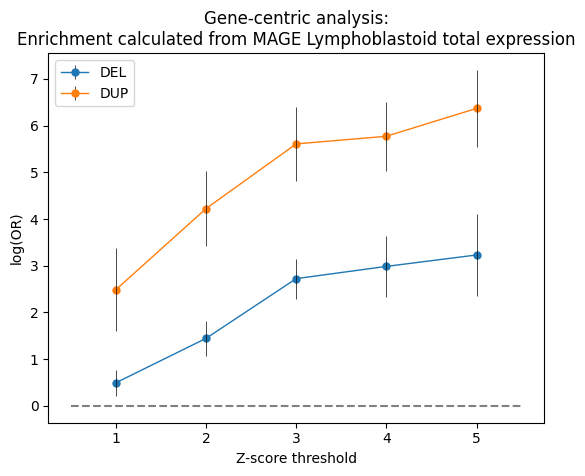

In [14]:
ci_included = relative_risk_confidence_interval(rare_sv_genes_enrichment_collapse_noConflict.to_pandas())

for svtype in ['DEL','DUP']:
    ci_included['Relative Risk'] = ci_included['1,1']/(ci_included['1,1']+ci_included['1,0'])/\
    (ci_included['0,1']/(ci_included['0,1']+ci_included['0,0']))
    plt.errorbar(ci_included.loc[ci_included['SVTYPE']==svtype,'Z-threshold'],
                 ci_included.loc[ci_included['SVTYPE']==svtype,'log_RR'],
                 ci_included.loc[ci_included['SVTYPE']==svtype,['dlog_lowB','dlog_highB']].to_numpy().T,
                 label=svtype,
                 ecolor='black',
                 elinewidth=0.5,barsabove=True,
                 linewidth=1,marker='.',markersize=10)
plt.hlines(y=0,xmax=5.5,xmin=0.5,linestyles='dashed',colors='gray')
plt.legend(loc='upper left')
plt.title('Gene-centric analysis:\nEnrichment calculated from MAGE Lymphoblastoid total expression')
plt.xlabel('Z-score threshold')
plt.ylabel('log(OR)')

The above plot shows the enrichment for different SV types for different severities of outliers. Only SVs overlapping the genes are considered.

# Over-/Under-expression outlier analysis

## Enrichment of _overexpression_ outliers

In [15]:
rare_svs=MAFs.with_columns(pl.when(pl.col('af')<0.01).then('rare').otherwise('common').alias('rareness')).select(['SV','af','rareness']).collect()
rare_svs_30=rare_svs.filter(pl.col('SV').is_in(svlen_gt_30))

rare_genotypes = sv_genotypes.filter((pl.col('Allele')>0)).join(rare_svs_30.lazy(),on='SV').\
collect().rename({'SUBJID':'Ind'}).lazy()
genotype_ind = set(rare_genotypes.select('Ind').collect()['Ind'])
expression_ind = set(lymphoblast.select('Ind').collect()['Ind'])
subset_to_use = list(genotype_ind.intersection(expression_ind))
relevant_outliers=lymphoblast.filter(pl.col('Ind').is_in(subset_to_use)).with_columns([pl.when(pl.col('MedZ') > i).then(1).otherwise(0).alias(f"Y{i}_over") for i in range(1,6)])
relevant_outliers=relevant_outliers.with_columns([pl.when(pl.col(f'Y{i}_over').sum().over('gene')>0).then(1).otherwise(0).alias(f"Y{i}_over_background") for i in range(1,6)])

rare_genotypes = rare_genotypes.filter(pl.col('Ind').is_in(subset_to_use))
rare_sv_enrichment = relevant_outliers.join(gene_sv_overlap.select(['gene','SV']),on='gene',how='left').\
join(rare_genotypes,on=['Ind','SV'],how='left').\
with_columns([
    pl.when(pl.col('rareness')=='rare').then(1).otherwise(0).alias('has_rare_SV'),
    pl.when(pl.col('rareness')=='common').then(1).otherwise(0).alias('has_common_SV'),
    pl.when((pl.col('rareness')=='rare')&(pl.col('SVTYPE')=='DUP')).then(1).otherwise(0).alias('has_rare_DUP'),
    pl.when((pl.col('rareness')=='rare')&(pl.col('SVTYPE')=='DEL')).then(1).otherwise(0).alias('has_rare_DEL'),
    pl.when((pl.col('rareness')=='rare')&(pl.col('SVTYPE')=='INS')).then(1).otherwise(0).alias('has_rare_INS'),
    pl.when((pl.col('rareness')=='rare')&(pl.col('SVTYPE')=='INV')).then(1).otherwise(0).alias('has_rare_INV'),
]).collect()

# Add coding sequence annotation
rare_sv_enrichment = rare_sv_enrichment.join(vep.select(['gene','SV','coding_sequence_variant']),on=['gene','SV'],how='left')
    
rare_sv_enrichment_gene = rare_sv_enrichment.groupby(['gene','Ind']).agg(pl.col("MedZ").first(),
                                                   pl.col("Y").first(),
                                                   pl.col("Y1_over").first(),
                                                   pl.col("Y2_over").first(),
                                                   pl.col("Y3_over").first(),
                                                   pl.col("Y4_over").first(),
                                                   pl.col("Y5_over").first(),
                                                   pl.col("Y1_over_background").first(),
                                                   pl.col("Y2_over_background").first(),
                                                   pl.col("Y3_over_background").first(),
                                                   pl.col("Y4_over_background").first(),
                                                   pl.col("Y5_over_background").first(),
                                                   pl.col("Allele").max(),
                                                   pl.col("has_rare_SV").max(),
                                                   pl.col("has_common_SV").max(),
                                                   pl.col("has_rare_DUP").max(),
                                                   pl.col("has_rare_DEL").max(),
                                                   pl.col("has_rare_INS").max(),
                                                   pl.col("has_rare_INV").max(),
                                                   pl.col('coding_sequence_variant').max())

enrichment_using_statsmodels = rare_sv_enrichment_gene.fill_null(0).select(['gene','MedZ','Ind',
                                                                                   'Y1_over','Y2_over','Y3_over','Y4_over','Y5_over',
                                                                                   'Y1_over_background','Y2_over_background',
                                                                                   'Y3_over_background','Y4_over_background',
                                                                                   'Y5_over_background','has_rare_SV','has_common_SV',
                                                                                   'has_rare_DUP','has_rare_DEL','has_rare_INS',
                                                                                   'has_rare_INV','coding_sequence_variant']).to_pandas()


In [16]:
enrichment_over_results = []
for i in range(1,6):
    model = smf.logit(f'Y{i}_over ~ has_rare_DUP + has_rare_DEL',
              data = enrichment_using_statsmodels[enrichment_using_statsmodels[f'Y{i}_over_background']==1]).fit()
    enrichment_over_results.append(pd.DataFrame({'SVTYPE':['DUP','DEL'],
                                                 'log_OR':[model.params['has_rare_DUP'],model.params['has_rare_DEL']],
                                                 'SE':[model.bse['has_rare_DUP'],model.bse['has_rare_DEL']],
                                                 'P-value': [model.pvalues['has_rare_DUP'],model.pvalues['has_rare_DEL']],
                                                 'Z-threshold':i}))
enrichment_over_df = pd.concat(enrichment_over_results)

Optimization terminated successfully.
         Current function value: 0.360223
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.095923
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.038434
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.028368
         Iterations 10
Optimization terminated successfully.
         Current function value: 0.018262
         Iterations 10


## Enrichment of _underexpression_ outliers

In [17]:
rare_svs=MAFs.with_columns(pl.when(pl.col('af')<0.01).then('rare').otherwise('common').alias('rareness')).select(['SV','af','rareness']).collect()
rare_svs_30=rare_svs.filter(pl.col('SV').is_in(svlen_gt_30))

rare_genotypes = sv_genotypes.filter((pl.col('Allele')>0)).join(rare_svs_30.lazy(),on='SV').\
collect().rename({'SUBJID':'Ind'}).lazy()
genotype_ind = set(rare_genotypes.select('Ind').collect()['Ind'])
expression_ind = set(lymphoblast.select('Ind').collect()['Ind'])
subset_to_use = list(genotype_ind.intersection(expression_ind))
relevant_outliers=lymphoblast.filter(pl.col('Ind').is_in(subset_to_use)).with_columns([pl.when(pl.col('MedZ') < -i).then(1).otherwise(0).alias(f"Y{i}_under") for i in range(1,6)])
relevant_outliers=relevant_outliers.with_columns([pl.when(pl.col(f'Y{i}_under').sum().over('gene')>0).then(1).otherwise(0).alias(f"Y{i}_under_background") for i in range(1,6)])

rare_genotypes = rare_genotypes.filter(pl.col('Ind').is_in(subset_to_use))

rare_sv_enrichment = relevant_outliers.join(gene_sv_overlap.select(['gene','SV']),on='gene',how='left').\
join(rare_genotypes,on=['Ind','SV'],how='left').\
with_columns([
    pl.when(pl.col('rareness')=='rare').then(1).otherwise(0).alias('has_rare_SV'),
    pl.when(pl.col('rareness')=='common').then(1).otherwise(0).alias('has_common_SV'),
    pl.when((pl.col('rareness')=='rare')&(pl.col('SVTYPE')=='DUP')).then(1).otherwise(0).alias('has_rare_DUP'),
    pl.when((pl.col('rareness')=='rare')&(pl.col('SVTYPE')=='DEL')).then(1).otherwise(0).alias('has_rare_DEL'),
    pl.when((pl.col('rareness')=='rare')&(pl.col('SVTYPE')=='INS')).then(1).otherwise(0).alias('has_rare_INS'),
    pl.when((pl.col('rareness')=='rare')&(pl.col('SVTYPE')=='INV')).then(1).otherwise(0).alias('has_rare_INV'),
]).collect()

# Add coding sequence annotation
rare_sv_enrichment = rare_sv_enrichment.join(vep.select(['gene','SV','coding_sequence_variant']),on=['gene','SV'],how='left')
    
rare_sv_enrichment_gene = rare_sv_enrichment.groupby(['gene','Ind']).agg(pl.col("MedZ").first(),
                                                   pl.col("Y").first(),
                                                   pl.col("Y1_under").first(),
                                                   pl.col("Y2_under").first(),
                                                   pl.col("Y3_under").first(),
                                                   pl.col("Y4_under").first(),
                                                   pl.col("Y5_under").first(),
                                                   pl.col("Y1_under_background").first(),
                                                   pl.col("Y2_under_background").first(),
                                                   pl.col("Y3_under_background").first(),
                                                   pl.col("Y4_under_background").first(),
                                                   pl.col("Y5_under_background").first(),
                                                   pl.col("Allele").max(),
                                                   pl.col("has_rare_SV").max(),
                                                   pl.col("has_common_SV").max(),
                                                   pl.col("has_rare_DUP").max(),
                                                   pl.col("has_rare_DEL").max(),
                                                   pl.col("has_rare_INS").max(),
                                                   pl.col("has_rare_INV").max(),
                                                   pl.col('coding_sequence_variant').max())

enrichment_using_statsmodels = rare_sv_enrichment_gene.fill_null(0).select(['gene','MedZ','Ind',
                                                                                   'Y1_under','Y2_under','Y3_under','Y4_under','Y5_under',
                                                                                   'Y1_under_background','Y2_under_background',
                                                                                   'Y3_under_background','Y4_under_background',
                                                                                   'Y5_under_background','has_rare_SV','has_common_SV',
                                                                                   'has_rare_DUP','has_rare_DEL','has_rare_INS',
                                                                                   'has_rare_INV','coding_sequence_variant']).to_pandas()


In [18]:
enrichment_under_results = []

for i in range(1,4): # NOTE: Can set this to 1,5 if using all samples. Otherwise fails to converge.
    model = smf.logit(f'Y{i}_under ~ has_rare_DUP + has_rare_DEL',
              data = enrichment_using_statsmodels[enrichment_using_statsmodels[f'Y{i}_under_background']==1]).fit(maxiter=1000)
    enrichment_under_results.append(pd.DataFrame({'SVTYPE':['DUP','DEL'],'log_OR':[model.params['has_rare_DUP'],model.params['has_rare_DEL']],
                                                  'SE':[model.bse['has_rare_DUP'],model.bse['has_rare_DEL']],
                                                  'P-value': [model.pvalues['has_rare_DUP'],model.pvalues['has_rare_DEL']],
                                                  'Z-threshold':i}))
enrichment_under_df = pd.concat(enrichment_under_results)

Optimization terminated successfully.
         Current function value: 0.406318
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.105633
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.044304
         Iterations 9


In [19]:
enrichment_under_df['outlier_type']='under-expression'
enrichment_over_df['outlier_type']='over-expression'

## Plots

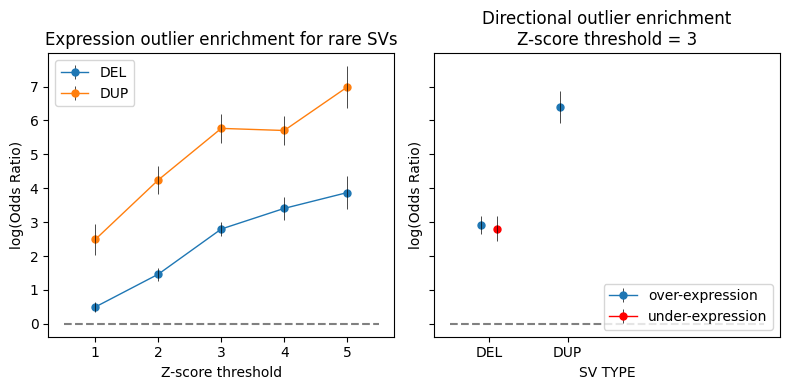

In [20]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8,4),sharey=True)

shift_x = 0
for svtype in ['DEL','DUP']:
    axs[0].errorbar(enrichment_df.loc[enrichment_df['SVTYPE']==svtype,'Z-threshold'],
                 enrichment_df.loc[enrichment_df['SVTYPE']==svtype,'log_OR'],
                 enrichment_df.loc[enrichment_df['SVTYPE']==svtype,['SE','SE']].to_numpy().T,
                 label=svtype,
                 ecolor='black',
                 elinewidth=0.5,barsabove=True,
                 linewidth=1,marker='.',markersize=10)
    plt.xticks([1,2],[1,2])
axs[0].hlines(y=0,xmax=5.5,xmin=0.5,linestyles='dashed',colors='gray')
axs[0].set_title("Expression outlier enrichment for rare SVs")
axs[0].set_xlabel("Z-score threshold")
axs[0].set_ylabel("log(Odds Ratio)")
axs[0].legend(loc='upper left')

Z_THRESH = 3

# overexpression
shift_x = 0
for svtype in ['DEL','DUP']:
    if svtype =='DEL':
        axs[1].errorbar(0.9+shift_x,
                     enrichment_over_df.loc[(enrichment_over_df['SVTYPE']==svtype)&
                                            (enrichment_over_df['Z-threshold']==Z_THRESH),'log_OR'],
                     enrichment_over_df.loc[(enrichment_over_df['SVTYPE']==svtype)&
                                            (enrichment_over_df['Z-threshold']==Z_THRESH),['SE','SE']].to_numpy().T,
                     label='over-expression',
                     ecolor='black',
                     elinewidth=0.5,barsabove=True,
                     linewidth=1,marker='.',markersize=10,c='#1f77b4')
        plt.xticks([1,2],['DEL','DUP'])
        shift_x+=1
    else:
        axs[1].errorbar(0.9+shift_x,
                     enrichment_over_df.loc[(enrichment_over_df['SVTYPE']==svtype)&
                                            (enrichment_over_df['Z-threshold']==Z_THRESH),'log_OR'],
                     enrichment_over_df.loc[(enrichment_over_df['SVTYPE']==svtype)&
                                            (enrichment_over_df['Z-threshold']==Z_THRESH),['SE','SE']].to_numpy().T,
                     ecolor='black',
                     elinewidth=0.5,barsabove=True,
                     linewidth=1,marker='.',markersize=10,c='#1f77b4')
        plt.xticks([1,2],['DEL','DUP'])
        shift_x+=1

# underexpression
shift_x = 0
for svtype in ['DEL']: # There were no DUP under-expression outliers, and including DUP here breaks the plot.
    axs[1].errorbar(1.1,
                 enrichment_under_df.loc[(enrichment_under_df['SVTYPE']==svtype)&
                                        (enrichment_under_df['Z-threshold']==Z_THRESH),'log_OR'],
                 enrichment_under_df.loc[(enrichment_under_df['SVTYPE']==svtype)&
                                        (enrichment_under_df['Z-threshold']==Z_THRESH),['SE','SE']].to_numpy().T,
                 label='under-expression',
                 ecolor='black',
                 elinewidth=0.5,barsabove=True,
                 linewidth=1,marker='.',markersize=10,c='red')
    plt.xticks([1,2],['DEL','DUP'])
    if svtype=='DEL':
        axs[1].legend(loc='lower right')
axs[1].hlines(y=0,xmax=4.5,xmin=0.5,linestyles='dashed',colors='gray')
axs[1].set_title("Directional outlier enrichment\nZ-score threshold = 3")
axs[1].set_xlabel("SV TYPE")
axs[1].set_ylabel("log(Odds Ratio)")
plt.tight_layout()

# There is not enough data to show any DUP underexpression outliers.
# There is not enough data to show Z>4 DEL underexpression outliers unless we use all samples.
# If we were to look at the Z>4 outliers (more extreme than Z>3), we would see that DELs are more enriched for underexpression than overexpression.

Same as the 10kb flank analysis, but with an additional plot showing the log(Odds ratio) of over-/under-expression outliers separately.

Text(0.5, 0.98, 'Lymphoblastoid outlier enrichment for rare SVs: MAGE')

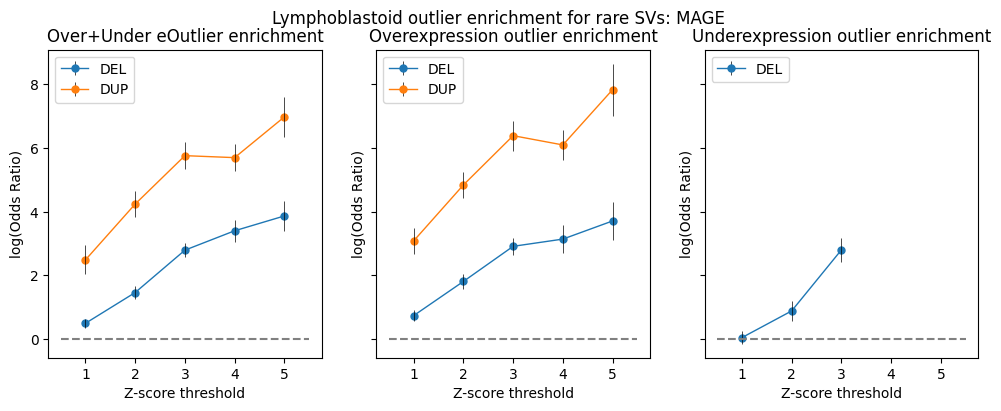

In [21]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12,4),sharey=True)
# over-and-under expression
shift_x = 0
for svtype in ['DEL','DUP']:
    axs[0].errorbar(enrichment_df.loc[enrichment_df['SVTYPE']==svtype,'Z-threshold'],
                 enrichment_df.loc[enrichment_df['SVTYPE']==svtype,'log_OR'],
                 enrichment_df.loc[enrichment_df['SVTYPE']==svtype,['SE','SE']].to_numpy().T,
                 label=svtype,
                 ecolor='black',
                 elinewidth=0.5,barsabove=True,
                 linewidth=1,marker='.',markersize=10)
    plt.xticks([1,2,3,4,5],[1,2,3,4,5])
axs[0].hlines(y=0,xmax=5.5,xmin=0.5,linestyles='dashed',colors='gray')
axs[0].set_title("Over+Under eOutlier enrichment")
axs[0].set_xlabel("Z-score threshold")
axs[0].set_ylabel("log(Odds Ratio)")
axs[0].legend(loc='upper left')

# overexpression
shift_x = 0
for svtype in ['DEL','DUP']:
    axs[1].errorbar(enrichment_over_df.loc[enrichment_over_df['SVTYPE']==svtype,'Z-threshold'],
                 enrichment_over_df.loc[enrichment_over_df['SVTYPE']==svtype,'log_OR'],
                 enrichment_over_df.loc[enrichment_over_df['SVTYPE']==svtype,['SE','SE']].to_numpy().T,
                 label=svtype,
                 ecolor='black',
                 elinewidth=0.5,barsabove=True,
                 linewidth=1,marker='.',markersize=10)
    plt.xticks([1,2,3,4,5],[1,2,3,4,5])
axs[1].hlines(y=0,xmax=5.5,xmin=0.5,linestyles='dashed',colors='gray')
axs[1].set_title("Overexpression outlier enrichment")
axs[1].set_xlabel("Z-score threshold")
axs[1].set_ylabel("log(Odds Ratio)")
axs[1].legend(loc='upper left')

# underexpression
shift_x = 0
for svtype in ['DEL']: # There were no DUP under-expression outliers, and including DUP here breaks the plot.
    axs[2].errorbar(enrichment_under_df.loc[enrichment_under_df['SVTYPE']==svtype,'Z-threshold'],
                 enrichment_under_df.loc[enrichment_under_df['SVTYPE']==svtype,'log_OR'],
                 enrichment_under_df.loc[enrichment_under_df['SVTYPE']==svtype,['SE','SE']].to_numpy().T,
                 label=svtype,
                 ecolor='black',
                 elinewidth=0.5,barsabove=True,
                 linewidth=1,marker='.',markersize=10)
    plt.xticks([1,2,3,4,5],[1,2,3,4,5])
axs[2].hlines(y=0,xmax=5.5,xmin=0.5,linestyles='dashed',colors='gray')
axs[2].set_title("Underexpression outlier enrichment")
axs[2].set_xlabel("Z-score threshold")
axs[2].set_ylabel("log(Odds Ratio)")
axs[2].legend(loc='upper left')
plt.suptitle('Lymphoblastoid outlier enrichment for rare SVs: MAGE')